Unzipping the data

In [31]:
# upload the zip file first
library(utils)

# check what files are available
list.files()

unzip("northstar_dataset.zip")
list.files("northstar_dataset")

[1] "northstar_dataset"     "northstar_dataset.zip" "sample_data"

[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "README.txt"          "vehicles.csv"

Loading the data

In [32]:
orders     <- read.csv("northstar_dataset/orders.csv")
deliveries <- read.csv("northstar_dataset/deliveries.csv")
complaints <- read.csv("northstar_dataset/complaints.csv")

head(orders)
head(deliveries)
head(complaints)

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
1,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
2,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
3,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
4,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
5,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
6,CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


Double checking the structure

In [33]:
str(deliveries)
str(complaints)

'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr  "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr  "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr  "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : chr  "2024-06-18 10:57:00" "2025-01-11 18:45:00" "2025-06-02 20:39:00" "2024-03-08 23:31:00" ...
 $ delivery_completed_at        : chr  "2024-06-19 09:05:59.904311" "2025-01-11 17:39:00.000000" "2025-06-02 21:45:32.366770" "2024-03-09 23:30:08.103702" ...
 $ delivery_status              : chr  "Failed" "OnTime" "OnTime" "Delayed" ...
 $ route_distance_km            : num  17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : int  1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rating_p

Installing and loading the sqldf

In [34]:
str(deliveries)
str(complaints)

'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr  "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr  "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr  "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : chr  "2024-06-18 10:57:00" "2025-01-11 18:45:00" "2025-06-02 20:39:00" "2024-03-08 23:31:00" ...
 $ delivery_completed_at        : chr  "2024-06-19 09:05:59.904311" "2025-01-11 17:39:00.000000" "2025-06-02 21:45:32.366770" "2024-03-09 23:30:08.103702" ...
 $ delivery_status              : chr  "Failed" "OnTime" "OnTime" "Delayed" ...
 $ route_distance_km            : num  17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : int  1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rating_p

SQL Queries

In [30]:
install.packages("sqldf")
library(sqldf)

# failed deliveries by zone
failed_by_zone <- sqldf("
SELECT o.pickup_zone,
  COUNT(*) AS failed_deliveries
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE d.delivery_status = 'Failed'
GROUP BY o.pickup_zone
ORDER BY failed_deliveries DESC
")
print(failed_by_zone)

# complaints by service type
complaints_by_service <- sqldf("
SELECT o.service_type,
  COUNT(*) AS total_complaints
FROM complaints c
JOIN orders o ON c.order_id = o.order_id
GROUP BY o.service_type
ORDER BY total_complaints DESC
")
print(complaints_by_service)

# driver route overrides - top 10
driver_overrides <- sqldf("
SELECT driver_id,
  SUM(manual_route_override_count) AS total_overrides
FROM deliveries
GROUP BY driver_id
ORDER BY total_overrides DESC
LIMIT 10
")
print(driver_overrides)

# avg resolution days by severity
resolution_time <- sqldf("
SELECT severity,
  AVG(resolution_days) AS avg_resolution_days
FROM complaints
GROUP BY severity
ORDER BY avg_resolution_days DESC
")
print(resolution_time)

# high value failed orders
high_value_failed <- sqldf("
SELECT o.order_id,
  o.service_type,
  o.order_value,
  d.delivery_status
FROM orders o
JOIN deliveries d ON o.order_id = d.order_id
WHERE d.delivery_status = 'Failed'
AND o.order_value > 100
ORDER BY o.order_value DESC
LIMIT 10
")
print(high_value_failed)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



   pickup_zone failed_deliveries
1    RiverSide                14
2         EAST                11
3          Ctr                11
4      Central                11
5      CENTRAL                11
6        South                10
7        north                 8
8         East                 8
9      Airport                 8
10        West                 7
11        WEST                 7
12       North                 7
13       NORTH                 7
14       SOUTH                 4
15   Riverside                 4
16     AIRPORT                 4
  service_type total_complaints
1    Passenger               84
2       Retail               83
3       Parcel               77
4     Business               39
5      Medical               37
   driver_id total_overrides
1       D127              17
2       D130              16
3       D087              16
4       D131              15
5       D108              15
6       D105              14
7       D069              14
8       D028   

Installing and loading ggplot2

In [35]:
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Summary Statistics

In [36]:
summary(deliveries[, c("route_distance_km",
                        "manual_route_override_count",
                        "customer_rating_post_delivery",
                        "fuel_or_charge_cost")])

 route_distance_km manual_route_override_count customer_rating_post_delivery
 Min.   : 1.200    Min.   :0.0000              Min.   :1.000                
 1st Qu.: 9.135    1st Qu.:0.0000              1st Qu.:3.360                
 Median :12.840    Median :1.0000              Median :4.040                
 Mean   :13.909    Mean   :0.9695              Mean   :3.865                
 3rd Qu.:16.835    3rd Qu.:2.0000              3rd Qu.:4.550                
 Max.   :41.940    Max.   :7.0000              Max.   :5.000                
                                               NA's   :14                   
 fuel_or_charge_cost
 Min.   : 2.500     
 1st Qu.: 9.925     
 Median :12.645     
 Mean   :12.841     
 3rd Qu.:15.697     
 Max.   :29.430     
                    

Delivery Status Bar Chart

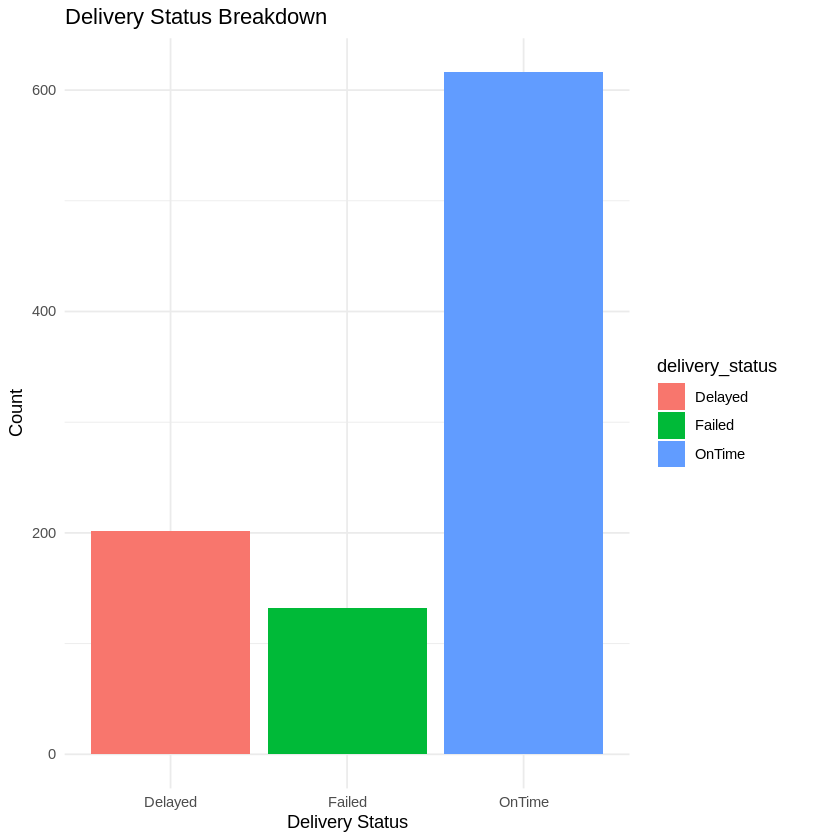

In [37]:
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  labs(title = "Delivery Status Breakdown",
       x = "Delivery Status",
       y = "Count") +
  theme_minimal()

Complaints by severity

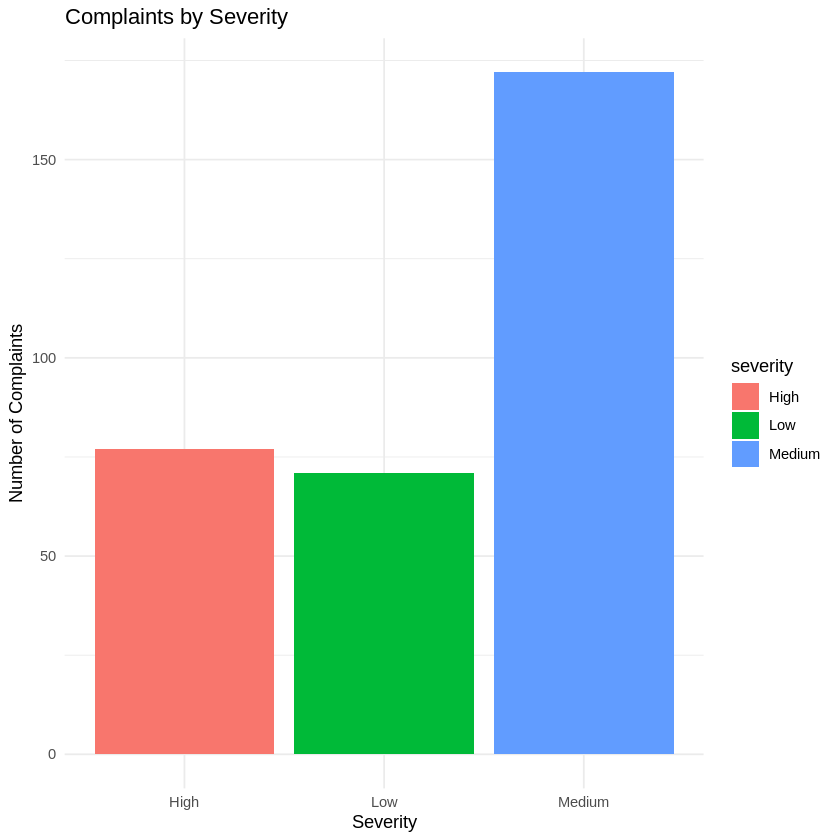

In [38]:
ggplot(complaints, aes(x = severity, fill = severity)) +
  geom_bar() +
  labs(title = "Complaints by Severity",
       x = "Severity",
       y = "Number of Complaints") +
  theme_minimal()

Customer ratings histogram

Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_bin()`).”


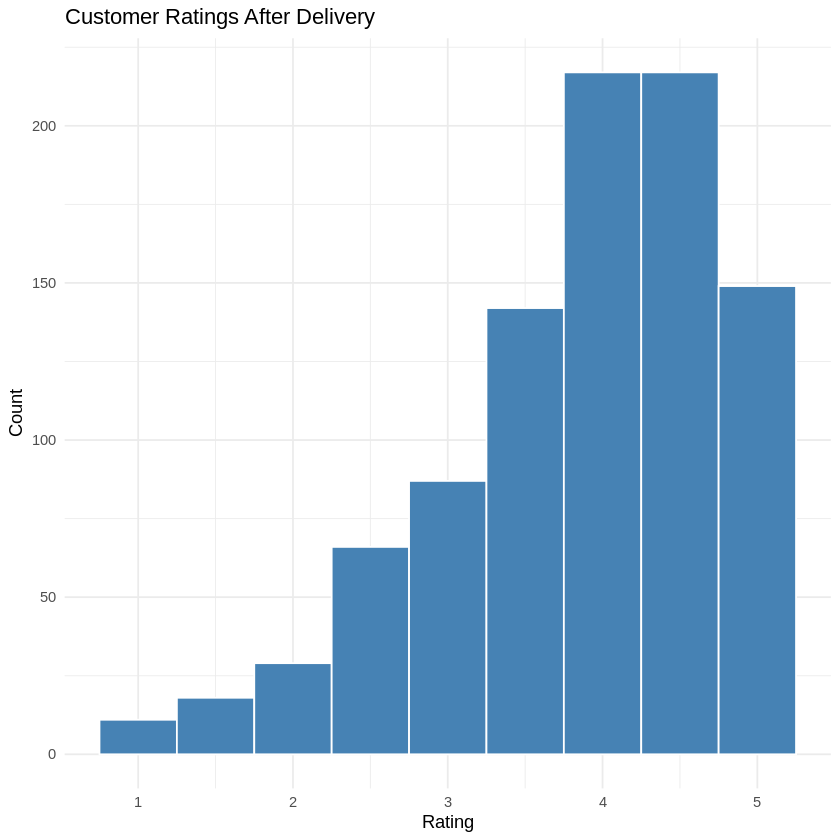

In [39]:
ggplot(deliveries, aes(x = customer_rating_post_delivery)) +
  geom_histogram(binwidth = 0.5, fill = "steelblue", color = "white") +
  labs(title = "Customer Ratings After Delivery",
       x = "Rating",
       y = "Count") +
  theme_minimal()

Ratings by delivery status

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


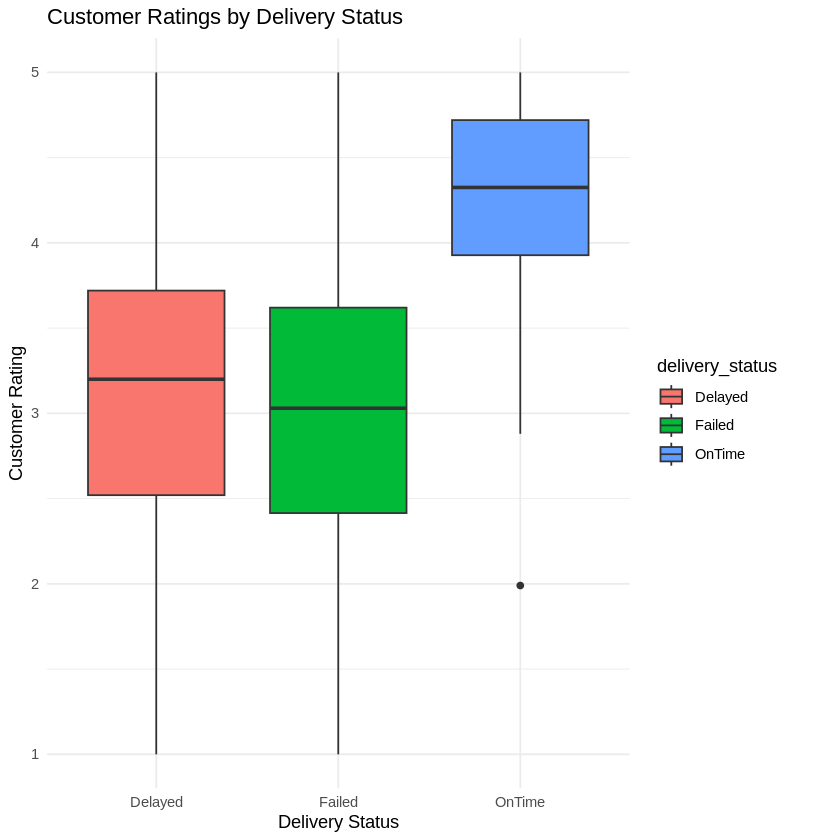

In [40]:
ggplot(deliveries, aes(x = delivery_status,
                        y = customer_rating_post_delivery,
                        fill = delivery_status)) +
  geom_boxplot() +
  labs(title = "Customer Ratings by Delivery Status",
       x = "Delivery Status",
       y = "Customer Rating") +
  theme_minimal()